# Clinically-Aware Multi-Stage Brain Tumor Intelligence System

Colab-ready, stage-by-stage notebook for MRI tumor detection, classification, uncertainty analysis, and explainability.

Notes:
- Default dataset path: `/content/mritumor/dataset`
- Run cells in order to validate each stage.
- This notebook uses transfer learning with model selection across multiple backbones.

In [3]:
import os
import sys


def _is_colab():
    return "google.colab" in sys.modules


# Set data root for local GPU runs. Change this path to your dataset location.
if _is_colab():
    os.environ.setdefault("MRI_DATA_ROOT", "/content/mritumor/dataset")
else:
    os.environ.setdefault("MRI_DATA_ROOT", "/Users/nuthanreddysurukunti/Downloads/mritumor/dataset")

print("MRI_DATA_ROOT:", os.environ.get("MRI_DATA_ROOT"))
print("Running in Colab:", _is_colab())

MRI_DATA_ROOT: /Users/nuthanreddysurukunti/Downloads/mritumor/dataset
Running in Colab: False


## 1) Colab Setup and Environment Checks
Install/import dependencies, verify GPU, set seeds, and define data paths.

In [4]:
# If running in Colab and TensorFlow is missing or outdated, uncomment:
# !pip -q install -U tensorflow

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = os.environ.get("MRI_DATA_ROOT", "/content/mritumor/dataset")
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR exists:", os.path.isdir(TRAIN_DIR))
print("TEST_DIR exists:", os.path.isdir(TEST_DIR))

IMG_SIZE = (224, 224)
IMG_CHANNELS = 3
INPUT_SHAPE = IMG_SIZE + (IMG_CHANNELS,)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES_ALL = ["glioma", "meningioma", "notumor", "pituitary"]
TUMOR_CLASSES = ["glioma", "meningioma", "pituitary"]

Matplotlib is building the font cache; this may take a moment.


TensorFlow: 2.21.0
GPU Available: []
DATA_ROOT: /Users/nuthanreddysurukunti/Downloads/mritumor/dataset
TRAIN_DIR exists: True
TEST_DIR exists: True


## 2) Stage 1: MRI Preprocessing Pipeline
Normalization, resizing, and augmentation. Visualize batches to verify preprocessing.

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.


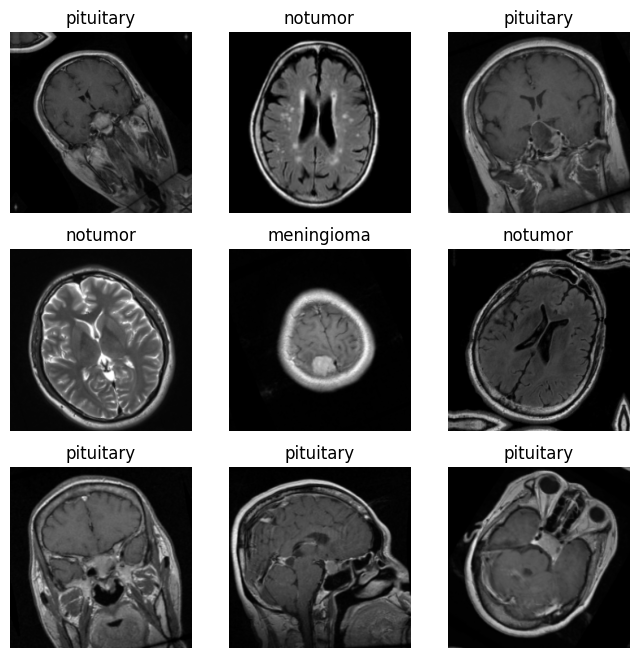

In [5]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

rescale = tf.keras.layers.Rescaling(1.0 / 255, name="rescale")


def ensure_rgb(x):
    if x.shape.rank == 4 and x.shape[-1] == 1:
        return tf.image.grayscale_to_rgb(x)
    return x


def make_base_ds(directory, class_names, subset=None, validation_split=None, shuffle=True):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=class_names,
        image_size=IMG_SIZE,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
        validation_split=validation_split,
        subset=subset,
    )


def prep_stage1(ds, augment=False):
    ds = ds.map(lambda x, y: (tf.cast(ensure_rgb(x), tf.float32), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


train_ds_stage1 = make_base_ds(TRAIN_DIR, CLASS_NAMES_ALL, subset="training", validation_split=0.2)
val_ds_stage1 = make_base_ds(TRAIN_DIR, CLASS_NAMES_ALL, subset="validation", validation_split=0.2)

train_ds_stage1 = prep_stage1(train_ds_stage1, augment=True)
val_ds_stage1 = prep_stage1(val_ds_stage1, augment=False)

# Visual check
images, labels = next(iter(train_ds_stage1))
plt.figure(figsize=(8, 8))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(CLASS_NAMES_ALL[int(labels[i])])
    plt.axis("off")
plt.show()

## 3) Stage 2: Binary Tumor Detection Model
Transfer-learning CNN for tumor vs no-tumor, with model selection across multiple backbones.

In [6]:
def _build_backbone(constructor, shape, preprocess):
    try:
        base = constructor(include_top=False, weights="imagenet", input_shape=shape)
    except ValueError as e:
        # Fallback lets training continue even if cached pretrained weights are incompatible.
        print(f"Warning: failed to load ImageNet weights ({e}). Falling back to weights=None.")
        base = constructor(include_top=False, weights=None, input_shape=shape)
    return base, preprocess


def get_backbone(backbone_name, input_shape):
    shape = tuple(input_shape)
    if shape[-1] != 3:
        shape = shape[:2] + (3,)

    if backbone_name == "EfficientNetB0":
        base, preprocess = _build_backbone(
            tf.keras.applications.EfficientNetB0,
            shape,
            tf.keras.applications.efficientnet.preprocess_input,
        )
    elif backbone_name == "ResNet50":
        base, preprocess = _build_backbone(
            tf.keras.applications.ResNet50,
            shape,
            tf.keras.applications.resnet.preprocess_input,
        )
    elif backbone_name == "MobileNetV2":
        base, preprocess = _build_backbone(
            tf.keras.applications.MobileNetV2,
            shape,
            tf.keras.applications.mobilenet_v2.preprocess_input,
        )
    else:
        raise ValueError("Unsupported backbone: " + backbone_name)

    base.trainable = False
    return base, preprocess, shape


def prep_for_backbone(ds, preprocess_fn, augment=False):
    ds = ds.map(lambda x, y: (tf.cast(ensure_rgb(x), tf.float32), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


def to_binary_labels(ds, notumor_index):
    return ds.map(
        lambda x, y: (x, tf.cast(tf.not_equal(y, notumor_index), tf.int32)),
        num_parallel_calls=AUTOTUNE,
    )


def build_binary_model(backbone_name):
    base, preprocess_fn, backbone_input_shape = get_backbone(backbone_name, INPUT_SHAPE)

    inputs = tf.keras.Input(shape=backbone_input_shape)
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs, name=f"binary_{backbone_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=["accuracy"],
    )
    return model, preprocess_fn


# Build base datasets (4 classes), then map to binary
train_ds_all = make_base_ds(TRAIN_DIR, CLASS_NAMES_ALL, subset="training", validation_split=0.2)
val_ds_all = make_base_ds(TRAIN_DIR, CLASS_NAMES_ALL, subset="validation", validation_split=0.2)

notumor_index = CLASS_NAMES_ALL.index("notumor")
train_ds_bin = to_binary_labels(train_ds_all, notumor_index)
val_ds_bin = to_binary_labels(val_ds_all, notumor_index)

BACKBONES = ["EfficientNetB0", "ResNet50", "MobileNetV2"]
EPOCHS_SHORT = 3

best_backbone = None
best_val_acc = -1.0
binary_models = {}

for bb in BACKBONES:
    model, preprocess_fn = build_binary_model(bb)
    train_ds = prep_for_backbone(train_ds_bin, preprocess_fn, augment=True)
    val_ds = prep_for_backbone(val_ds_bin, preprocess_fn, augment=False)

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_SHORT, verbose=1)
    val_acc = max(history.history.get("val_accuracy", [0.0]))

    binary_models[bb] = (model, preprocess_fn)
    print(f"{bb} val_accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_backbone = bb

print("Best backbone for detection:", best_backbone, "val_accuracy=", best_val_acc)

# Full training on best backbone
EPOCHS_FULL = 20
best_model, best_preprocess = binary_models[best_backbone]
train_ds = prep_for_backbone(train_ds_bin, best_preprocess, augment=True)
val_ds = prep_for_backbone(val_ds_bin, best_preprocess, augment=False)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
]

history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FULL,
    callbacks=callbacks,
    verbose=1,
)

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 32s 2us/step
Epoch 1/3
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 209ms/step - accuracy: 0.7247 - loss: 0.5442 - val_accuracy: 0.7583 - val_loss: 0.4876
Epoch 2/3
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 205ms/step - accuracy: 0.8219 - loss: 0.4061 - val_accuracy: 0.8345 - val_loss: 0.4020
Epoch 3/3
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 211ms/step - accuracy: 0.8685 - loss: 0.3419 - val_accuracy: 0.8739 - val_loss: 0.3509
EfficientNetB0 val_accuracy=0.8739
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 176s 2us/step
Epoch 1/3
143/143 ━━━━━━━━━━━━━━━━━━━━ 90s 616ms/step - accuracy: 0.7201 - loss: 0.5779 - val_accuracy: 0.8538 - val_loss: 0.3296
Epoch 2/3
143/143 ━━━━━━━━━━━━━━━━━━━━ 97s 674ms/step - accuracy: 0.8689 - loss: 0.3196 - val_accuracy: 0.9107 - val_loss: 0.2490
Epoch 3/3
143/143 ━━━━━━━━━━━━━━━━━━━━ 99s 691ms/step - accuracy

In [7]:
test_ds_all = make_base_ds(TEST_DIR, CLASS_NAMES_ALL, subset=None, validation_split=None, shuffle=False)
test_ds_bin = to_binary_labels(test_ds_all, notumor_index)
test_ds_bin = prep_for_backbone(test_ds_bin, best_preprocess, augment=False)

results = best_model.evaluate(test_ds_bin, verbose=1)
print("Detection test metrics:", dict(zip(best_model.metrics_names, results)))

Found 1311 files belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 515ms/step - accuracy: 0.9580 - loss: 0.1192
Detection test metrics: {'loss': 0.11920207738876343, 'compile_metrics': 0.9580472707748413}


## 4) Stage 3: Multi-Class Tumor Classification Model
Train a softmax classifier for glioma, meningioma, and pituitary (tumor-only images).

In [8]:
def build_multiclass_model(backbone_name, num_classes):
    base, preprocess_fn, backbone_input_shape = get_backbone(backbone_name, INPUT_SHAPE)

    inputs = tf.keras.Input(shape=backbone_input_shape)
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name=f"multiclass_{backbone_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model, preprocess_fn


train_ds_tumor = make_base_ds(TRAIN_DIR, TUMOR_CLASSES, subset="training", validation_split=0.2)
val_ds_tumor = make_base_ds(TRAIN_DIR, TUMOR_CLASSES, subset="validation", validation_split=0.2)

EPOCHS_SHORT = 3
best_backbone_mc = None
best_val_acc_mc = -1.0
multiclass_models = {}

for bb in BACKBONES:
    model, preprocess_fn = build_multiclass_model(bb, num_classes=len(TUMOR_CLASSES))
    train_ds = prep_for_backbone(train_ds_tumor, preprocess_fn, augment=True)
    val_ds = prep_for_backbone(val_ds_tumor, preprocess_fn, augment=False)

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_SHORT, verbose=1)
    val_acc = max(history.history.get("val_accuracy", [0.0]))

    multiclass_models[bb] = (model, preprocess_fn)
    print(f"{bb} val_accuracy={val_acc:.4f}")

    if val_acc > best_val_acc_mc:
        best_val_acc_mc = val_acc
        best_backbone_mc = bb

print("Best backbone for classification:", best_backbone_mc, "val_accuracy=", best_val_acc_mc)

# Full training on best backbone
EPOCHS_FULL = 20
best_model_mc, best_preprocess_mc = multiclass_models[best_backbone_mc]
train_ds = prep_for_backbone(train_ds_tumor, best_preprocess_mc, augment=True)
val_ds = prep_for_backbone(val_ds_tumor, best_preprocess_mc, augment=False)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
]

history = best_model_mc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FULL,
    callbacks=callbacks,
    verbose=1,
)

# Evaluate on tumor-only test set
test_ds_tumor = make_base_ds(TEST_DIR, TUMOR_CLASSES, subset=None, validation_split=None, shuffle=False)
test_ds_tumor = prep_for_backbone(test_ds_tumor, best_preprocess_mc, augment=False)

results = best_model_mc.evaluate(test_ds_tumor, verbose=1)
print("Classification test metrics:", dict(zip(best_model_mc.metrics_names, results)))

Found 4117 files belonging to 3 classes.
Using 3294 files for training.
Found 4117 files belonging to 3 classes.
Using 823 files for validation.
Epoch 1/3
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 226ms/step - accuracy: 0.4183 - loss: 1.1071 - val_accuracy: 0.5808 - val_loss: 0.9558
Epoch 2/3
103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.5771 - loss: 0.9130 - val_accuracy: 0.6355 - val_loss: 0.8369
Epoch 3/3
103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.6475 - loss: 0.8095 - val_accuracy: 0.6841 - val_loss: 0.7607
EfficientNetB0 val_accuracy=0.6841
Epoch 1/3
103/103 ━━━━━━━━━━━━━━━━━━━━ 72s 678ms/step - accuracy: 0.3953 - loss: 1.3535 - val_accuracy: 0.5930 - val_loss: 0.8896
Epoch 2/3
103/103 ━━━━━━━━━━━━━━━━━━━━ 68s 660ms/step - accuracy: 0.5577 - loss: 0.9678 - val_accuracy: 0.7351 - val_loss: 0.6899
Epoch 3/3
103/103 ━━━━━━━━━━━━━━━━━━━━ 65s 625ms/step - accuracy: 0.6451 - loss: 0.8176 - val_accuracy: 0.7776 - val_loss: 0.6001
ResNet50 val_accuracy=0.7776
Epoch 1/3
1

## 5) Stage 4: Confidence and Uncertainty (MC Dropout)
Use Monte Carlo Dropout to estimate predictive uncertainty and flag cases for review.

In [9]:
def mc_dropout_predict(model, images, n_samples=25):
    preds = []
    for _ in range(n_samples):
        preds.append(model(images, training=True))
    preds = tf.stack(preds, axis=0)
    mean_pred = tf.reduce_mean(preds, axis=0)
    return mean_pred


def predictive_entropy(probs):
    return -tf.reduce_sum(probs * tf.math.log(probs + 1e-8), axis=-1)


# Take a small batch from tumor test set
sample_images, _ = next(iter(test_ds_tumor))
mean_probs = mc_dropout_predict(best_model_mc, sample_images, n_samples=30)
entropy = predictive_entropy(mean_probs)

for i in range(min(5, sample_images.shape[0])):
    pred_idx = int(tf.argmax(mean_probs[i]).numpy())
    pred_label = TUMOR_CLASSES[pred_idx]
    conf = float(tf.reduce_max(mean_probs[i]).numpy())
    ent = float(entropy[i].numpy())
    flag = ent > 1.0
    print(f"Sample {i}: label={pred_label}, conf={conf:.3f}, entropy={ent:.3f}, uncertain={flag}")

Sample 0: label=glioma, conf=0.948, entropy=0.219, uncertain=False
Sample 1: label=glioma, conf=0.714, entropy=0.796, uncertain=False
Sample 2: label=glioma, conf=0.989, entropy=0.067, uncertain=False
Sample 3: label=glioma, conf=0.617, entropy=0.764, uncertain=False
Sample 4: label=glioma, conf=0.656, entropy=0.881, uncertain=False


## 7) Stage 6: Clinical Decision Support Output Formatting
Assemble structured outputs (tumor type, confidence, uncertainty flag, and explanation pointers).

In [11]:
def build_clinical_report(image_id, probs, entropy_value, entropy_threshold=1.0):
    pred_idx = int(tf.argmax(probs).numpy())
    pred_label = TUMOR_CLASSES[pred_idx]
    confidence = float(tf.reduce_max(probs).numpy())
    uncertain = bool(entropy_value > entropy_threshold)

    report = {
        "image_id": image_id,
        "predicted_tumor_type": pred_label,
        "confidence": round(confidence, 4),
        "predictive_entropy": round(float(entropy_value), 4),
        "uncertain_flag": uncertain,
        "review_recommendation": "Review by expert" if uncertain else "Routine review",
    }
    return report


# Example report from a batch
sample_images, _ = next(iter(test_ds_tumor))
mean_probs = mc_dropout_predict(best_model_mc, sample_images, n_samples=30)
entropy = predictive_entropy(mean_probs)

report = build_clinical_report("example_image_001", mean_probs[0], entropy[0])
print(report)

{'image_id': 'example_image_001', 'predicted_tumor_type': 'glioma', 'confidence': 0.9636, 'predictive_entropy': 0.1634, 'uncertain_flag': False, 'review_recommendation': 'Routine review'}


In [12]:
# Save the trained model
MODEL_SAVE_PATH = os.path.join(DATA_ROOT, "best_model_mc.keras")
best_model_mc.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")
print(f"File size: {os.path.getsize(MODEL_SAVE_PATH) / (1024**2):.2f} MB")

# Also save the preprocessing function details for later inference
import json
preprocessing_info = {
    "backbone": best_backbone_mc,
    "classes": TUMOR_CLASSES,
    "input_shape": list(INPUT_SHAPE),
    "image_size": list(IMG_SIZE),
}
info_path = os.path.join(DATA_ROOT, "model_info.json")
with open(info_path, "w") as f:
    json.dump(preprocessing_info, f, indent=2)
print(f"Model info saved to: {info_path}")

Model saved to: /Users/nuthanreddysurukunti/Downloads/mritumor/dataset/best_model_mc.keras
File size: 90.68 MB
Model info saved to: /Users/nuthanreddysurukunti/Downloads/mritumor/dataset/model_info.json
